In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.models.train import (
    train_logistic_regression,
    train_xgboost,
    train_lightgbm,
    log_to_mlflow
)
from src.models.evaluate import (
    evaluate_model,
    plot_roc_curve,
    calculate_gini,
    calculate_ks_statistic
)

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("All imports successful")

All imports successful


In [2]:
X_train = pd.read_csv('../data/processed/X_train_woe.csv', index_col=0)
X_test  = pd.read_csv('../data/processed/X_test_woe.csv',  index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv',     index_col=0).squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv',      index_col=0).squeeze()

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")
print(f"\nDefault rate in train : {y_train.mean()*100:.2f}%")
print(f"Default rate in test  : {y_test.mean()*100:.2f}%")
print(f"\nFeatures used for training:")
for col in X_train.columns:
    print(f"  - {col}")

X_train shape : (246008, 30)
X_test shape  : (61503, 30)
y_train shape : (246008,)
y_test shape  : (61503,)

Default rate in train : 8.07%
Default rate in test  : 8.07%

Features used for training:
  - EXT_SOURCE_3
  - EXT_SOURCE_2
  - CREDIT_TO_ANNUITY_RATIO
  - DAYS_EMPLOYED
  - YEARS_EMPLOYED
  - AMT_GOODS_PRICE
  - EMPLOYMENT_TO_AGE_RATIO
  - DAYS_BIRTH
  - AGE_YEARS
  - ORGANIZATION_TYPE
  - NAME_INCOME_TYPE
  - OCCUPATION_TYPE
  - NAME_EDUCATION_TYPE
  - AMT_CREDIT
  - DAYS_LAST_PHONE_CHANGE
  - CODE_GENDER
  - DAYS_ID_PUBLISH
  - REGION_POPULATION_RELATIVE
  - REGION_RATING_CLIENT_W_CITY
  - TOTALAREA_MODE
  - REGION_RATING_CLIENT
  - DAYS_REGISTRATION
  - FLOORSMAX_AVG
  - FLOORSMAX_MEDI
  - FLOORSMAX_MODE
  - YEARS_BEGINEXPLUATATION_MEDI
  - YEARS_BEGINEXPLUATATION_AVG
  - AMT_ANNUITY
  - YEARS_BEGINEXPLUATATION_MODE
  - NAME_FAMILY_STATUS


In [3]:
lr_model, scaler, lr_metrics, X_train_scaled, X_test_scaled = train_logistic_regression(
    X_train    = X_train,
    X_test     = X_test,
    y_train    = y_train,
    y_test     = y_test,
    save_path  = '../models'
)


TRAINING LOGISTIC REGRESSION
Logistic Regression trained successfully
EVALUATION REPORT — Logistic Regression

Metric                              Train       Test
--------------------------------------------------
AUC                                0.7409     0.7446
Gini Coefficient                   0.4818     0.4891
KS Statistic                        36.18      36.72

MCC (Test only)                    0.2078
PSI (Train vs Test)                0.0001
PSI Status                         Stable

Confusion Matrix (Test Set, threshold=0.5):
  True Negatives  (Repaid, predicted Repaid)    : 38,479
  False Positives (Repaid, predicted Default)   : 18,059
  False Negatives (Default, predicted Repaid)   : 1,574
  True Positives  (Default, predicted Default)  : 3,391

Classification Report (Test Set):
              precision    recall  f1-score   support

      Repaid       0.96      0.68      0.80     56538
     Default       0.16      0.68      0.26      4965

    accuracy                

In [4]:
xgb_model, xgb_metrics = train_xgboost(
    X_train = X_train,
    X_test  = X_test,
    y_train = y_train,
    y_test  = y_test
)


TRAINING XGBOOST (for comparison)
scale_pos_weight set to : 11.39
XGBoost trained successfully
EVALUATION REPORT — XGBoost

Metric                              Train       Test
--------------------------------------------------
AUC                                0.7639     0.7518
Gini Coefficient                   0.5278     0.5037
KS Statistic                        39.67      37.98

MCC (Test only)                    0.2178
PSI (Train vs Test)                0.0001
PSI Status                         Stable

Confusion Matrix (Test Set, threshold=0.5):
  True Negatives  (Repaid, predicted Repaid)    : 39,327
  False Positives (Repaid, predicted Default)   : 17,211
  False Negatives (Default, predicted Repaid)   : 1,580
  True Positives  (Default, predicted Default)  : 3,385

Classification Report (Test Set):
              precision    recall  f1-score   support

      Repaid       0.96      0.70      0.81     56538
     Default       0.16      0.68      0.26      4965

    accuracy   

In [5]:
lgbm_model, lgbm_metrics = train_lightgbm(
    X_train = X_train,
    X_test  = X_test,
    y_train = y_train,
    y_test  = y_test
)


TRAINING LIGHTGBM (for comparison)
LightGBM trained successfully
EVALUATION REPORT — LightGBM

Metric                              Train       Test
--------------------------------------------------
AUC                                0.7634     0.7514
Gini Coefficient                   0.5268     0.5027
KS Statistic                        39.51      37.74

MCC (Test only)                    0.2172
PSI (Train vs Test)                0.0002
PSI Status                         Stable

Confusion Matrix (Test Set, threshold=0.5):
  True Negatives  (Repaid, predicted Repaid)    : 39,223
  False Positives (Repaid, predicted Default)   : 17,315
  False Negatives (Default, predicted Repaid)   : 1,574
  True Positives  (Default, predicted Default)  : 3,391

Classification Report (Test Set):
              precision    recall  f1-score   support

      Repaid       0.96      0.69      0.81     56538
     Default       0.16      0.68      0.26      4965

    accuracy                           0.69 

In [6]:
comparison = pd.DataFrame({
    'Model'           : ['Logistic Regression', 'XGBoost', 'LightGBM'],
    'AUC'             : [lr_metrics['test_auc'],   xgb_metrics['test_auc'],  lgbm_metrics['test_auc']],
    'Gini'            : [lr_metrics['test_gini'],  xgb_metrics['test_gini'], lgbm_metrics['test_gini']],
    'KS Statistic'    : [lr_metrics['test_ks'],    xgb_metrics['test_ks'],   lgbm_metrics['test_ks']],
    'MCC'             : [lr_metrics['test_mcc'],   xgb_metrics['test_mcc'],  lgbm_metrics['test_mcc']],
    'PSI'             : [lr_metrics['test_psi'],   xgb_metrics['test_psi'],  lgbm_metrics['test_psi']],
})

print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comparison.to_string(index=False))

print("""
DECISION — Why we choose Logistic Regression for the Scorecard
---------------------------------------------------------------
- XGBoost and LightGBM are only marginally better (AUC difference < 0.01)
- Logistic Regression is fully explainable and auditable
- Regulators and banks require explainability — black box models
  like XGBoost cannot be submitted for regulatory approval
- WoE transformed features are specifically designed to work
  best with Logistic Regression
- Logistic Regression produces well calibrated probabilities
  which are required for scorecard scaling
- All three models have stable PSI — no distribution shift

FINAL MODEL — Logistic Regression
  AUC  : {:.4f}
  Gini : {:.4f}
  KS   : {:.2f}
  PSI  : {:.4f} (Stable)
""".format(
    lr_metrics['test_auc'],
    lr_metrics['test_gini'],
    lr_metrics['test_ks'],
    lr_metrics['test_psi']
))

MODEL COMPARISON SUMMARY
              Model    AUC   Gini  KS Statistic    MCC    PSI
Logistic Regression 0.7446 0.4891       36.7156 0.2078 0.0001
            XGBoost 0.7518 0.5037       37.9779 0.2178 0.0001
           LightGBM 0.7514 0.5027       37.7441 0.2172 0.0002

DECISION — Why we choose Logistic Regression for the Scorecard
---------------------------------------------------------------
- XGBoost and LightGBM are only marginally better (AUC difference < 0.01)
- Logistic Regression is fully explainable and auditable
- Regulators and banks require explainability — black box models
  like XGBoost cannot be submitted for regulatory approval
- WoE transformed features are specifically designed to work
  best with Logistic Regression
- Logistic Regression produces well calibrated probabilities
  which are required for scorecard scaling
- All three models have stable PSI — no distribution shift

FINAL MODEL — Logistic Regression
  AUC  : 0.7446
  Gini : 0.4891
  KS   : 36.72
  PSI 

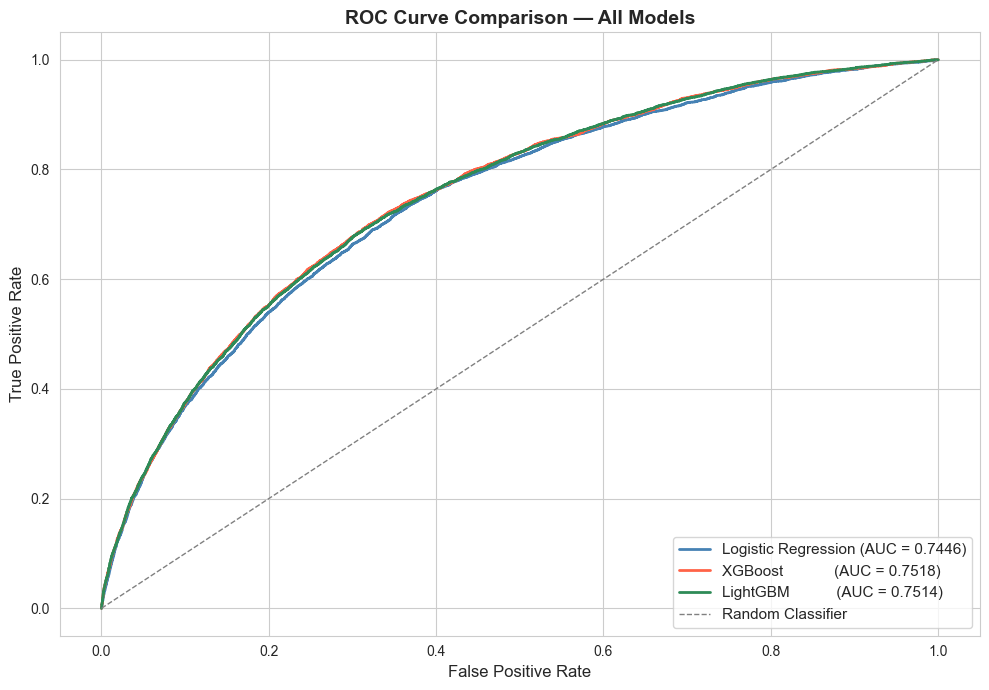

Plot saved to docs/roc_curve_comparison.png


In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for all three models
lr_probs   = lr_model.predict_proba(X_test_scaled)[:, 1]
xgb_probs  = xgb_model.predict_proba(X_test)[:, 1]
lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]

# Calculate ROC curves
lr_fpr,   lr_tpr,   _ = roc_curve(y_test, lr_probs)
xgb_fpr,  xgb_tpr,  _ = roc_curve(y_test, xgb_probs)
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_probs)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(lr_fpr,   lr_tpr,   color='steelblue', linewidth=2,
         label=f'Logistic Regression (AUC = {lr_metrics["test_auc"]:.4f})')
plt.plot(xgb_fpr,  xgb_tpr,  color='tomato',    linewidth=2,
         label=f'XGBoost            (AUC = {xgb_metrics["test_auc"]:.4f})')
plt.plot(lgbm_fpr, lgbm_tpr, color='seagreen',  linewidth=2,
         label=f'LightGBM           (AUC = {lgbm_metrics["test_auc"]:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('../docs/roc_curve_comparison.png', bbox_inches='tight')
plt.show()

print("Plot saved to docs/roc_curve_comparison.png")

In [8]:
log_to_mlflow(
    model_name = "Logistic_Regression",
    params     = {
        'C'            : 0.1,
        'class_weight' : 'balanced',
        'max_iter'     : 1000,
        'solver'       : 'lbfgs'
    },
    metrics    = lr_metrics,
    model      = lr_model
)

# Log XGBoost
log_to_mlflow(
    model_name = "XGBoost",
    params     = {
        'n_estimators'     : 300,
        'max_depth'        : 4,
        'learning_rate'    : 0.05,
        'subsample'        : 0.8,
        'colsample_bytree' : 0.8
    },
    metrics    = xgb_metrics,
    model      = xgb_model
)

# Log LightGBM
log_to_mlflow(
    model_name = "LightGBM",
    params     = {
        'n_estimators'     : 300,
        'max_depth'        : 4,
        'learning_rate'    : 0.05,
        'subsample'        : 0.8,
        'colsample_bytree' : 0.8
    },
    metrics    = lgbm_metrics,
    model      = lgbm_model
)

print("\nAll models logged to MLflow successfully")
print("Run 'mlflow ui' in your terminal to view the experiments")

C:\Users\sai charan\miniconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/28 03:55:22 INFO mlflow.tracking.fluent: Experiment with name 'credit_scoring' does not exist. Creating a new experiment.
2026/04/28 03:55:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 03:55:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the '


Logged to MLflow — experiment: credit_scoring, run: Logistic_Regression


2026/04/28 03:55:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/28 03:55:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Logged to MLflow — experiment: credit_scoring, run: XGBoost


2026/04/28 03:55:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Logged to MLflow — experiment: credit_scoring, run: LightGBM

All models logged to MLflow successfully
Run 'mlflow ui' in your terminal to view the experiments
